In [1]:
using Random
using Flux

In [4]:

function holdOut(N::Int, P::Real)
    @assert 0 <= P <= 1 "P debe estar entre 0 y 1"
    indices = randperm(N)  # Generate a random permutation of indexes
    split_point = floor(Int, N * (1 - P))  # Determines cut-off point
    return (indices[1:split_point], indices[split_point+1:end])  # Returns the tuple with the subdatasets
end

holdOut (generic function with 2 methods)

In [6]:
sets = holdOut(150, 0.3)
typeof(sets)


Tuple{Vector{Int64}, Vector{Int64}}

In [5]:

function holdOut(N::Int, Pval::Real, Ptest::Real)
    @assert 0 <= Pval + Ptest <= 1 "La suma de Pval y Ptest debe estar entre 0 y 1"
    (train_test, test) = holdOut(N, Ptest)  # Separates the test dataset
    Pval_adjusted = Pval / (1 - Ptest)  # Adjusts Pval for the remaining datasets 
    train, val = holdOut(length(train_test), Pval_adjusted)  # Separates validate dataset from training dataset
    return (train_test[train], train_test[val], test)  # Returns the three datasets
end

holdOut (generic function with 2 methods)

In [12]:
(a, b, c) = holdOut(150, 0.15, 0.15)
x = length(a) + length(b) + length(c)
typeof((a, b, c))


Tuple{Vector{Int64}, Vector{Int64}, Vector{Int64}}

In [89]:
function trainClassANN(topology::AbstractArray{<:Int,1},
    trainingDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}};
    validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0,size(trainingDataset[2],2))),
    testDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0,size(trainingDataset[2],2))),
    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)),
    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,
    maxEpochsVal::Int=20)

    println("hola")

    trainingInputs = Float32.(trainingDataset[1]') # Convertir inputs a float32
    validationInputs = Float32.(validationDataset[1]') # Convertir inputs a float32
    testInputs = Float32.(testDataset[1]') # Convertir inputs a float32

    trainingTargets = trainingDataset[2]' # Extraer labels
    validationTargets = validationDataset[2]' # Extraer labels
    testTargets = testDataset[2]' # Extraer labels
    
    numTrainingInputs = size(trainingInputs, 1)
    numTrainingOutputs = size(trainingTargets, 1)
    
    ann = buildClassANN(numTrainingInputs, topology, numTrainingOutputs; transferFunctions) # build ANN
    loss(model, x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y) # loss function
    
    opt_state = Flux.setup(Adam(learningRate), ann) 

    trainingLosses = Float32[] # losses array
    validationLosses = Float32[] # validation losses
    testLosses = Float32[] # test losses array

    push!(trainingLosses, loss(ann, trainingInputs, trainingTargets)) # append epoch 0 loss 

    if !isempty(validationInputs)
        push!(validationLosses, loss(ann, validationInputs, validationTargets))
    end
    if !isempty(testInputs)
        push!(testLosses, loss(ann, testInputs, testTargets))
    end

    bestValidationLoss = Inf
    bestAnn = deepcopy(ann)
    epochsWithoutImprovement = 0
    epochs = 0
    
    for epoch in 1:maxEpochs
      
        Flux.train!(loss, ann, [(trainingInputs, trainingTargets)], opt_state)
        epochs = epochs + 1
        currentTrainingLoss = loss(ann, trainingInputs, trainingTargets)
        push!(trainingLosses, currentTrainingLoss)
        
        if currentTrainingLoss <= minLoss
            break
        end
    
        # VALIDACIÓN (si hay conjunto de validación)
        if !isempty(validationInputs)
            currentValidationLoss = loss(ann, validationInputs, validationTargets)
            push!(validationLosses, currentValidationLoss)
            
            # PARADA TEMPRANA: Si el loss en validación mejora, actualizar mejor modelo
            if currentValidationLoss < bestValidationLoss
       
                bestValidationLoss = currentValidationLoss
                bestAnn = deepcopy(ann)
                epochsWithoutImprovement = 0  # Reiniciar el contador de epochs sin mejora
            else
                epochsWithoutImprovement += 1
            end
            
        end
    
        # PRUEBA (si hay conjunto de test)
        if !isempty(testInputs)
            currentTestLoss = loss(ann, testInputs, testTargets)
            push!(testLosses, currentTestLoss)
        end
    
        # CRITERIO DE PARADA TEMPRANA
        if epochsWithoutImprovement >= maxEpochsVal
            println("Parada temprana en epoch $epoch ")
            break
        end

    end

    println("Epochs completados: $epochs")
    println("Tamaño trainingLosses: $(length(trainingLosses))")
    println("Tamaño validationLosses: $(length(validationLosses))")
    println("Tamaño testLosses: $(length(testLosses))")
    
    if !isempty(validationInputs)
        return (bestAnn, trainingLosses, validationLosses, testLosses)
    else
        return (ann, trainingLosses, validationLosses, testLosses)
    end
end;
   

trainClassANN (generic function with 2 methods)

In [8]:
function trainClassANN(topology::AbstractArray{<:Int,1},
    trainingDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}};
    validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0)),
    testDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0)),
    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)),
    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,
    maxEpochsVal::Int=20) 

    newTrainingDataset = (trainingDataset[1], reshape(trainingDataset[2], :, 1))
    newValidationDataset = (validationDataset[1], reshape(validationDataset[2], :, 1))
    newTestDataset = (testDataset[1], reshape(testDataset[2], :, 1))

    return trainClassANN(topology, newTrainingDataset; validationDataset=newValidationDataset, testDataset=newTestDataset, 
                         transferFunctions=transferFunctions, maxEpochs=maxEpochs, minLoss=minLoss, 
                         learningRate=learningRate, maxEpochsVal=maxEpochsVal)
end

trainClassANN (generic function with 2 methods)

# Testing pipeline

In [56]:
# Cargamos el dataset
using DelimitedFiles: readdlm
include("/Users/rafa/Documents/Uni/Cuatri4/machine_learning/FAA_practices/src/boletin_1/45159263M_49918198X_48118738R_54153358L.jl")

dataset = readdlm(ruta_rafa,',')

# Preparamos las entradas
inputs = Float32.(dataset[:,1:4])
targets = oneHotEncoding(dataset[:,5])

150×3 Matrix{Bool}:
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 ⋮     
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1

In [57]:
inputs = normalizeZeroMean!(inputs)

150×4 Matrix{Float32}:
 -0.897675    1.02861   -1.33679   -1.30859
 -1.1392     -0.12454   -1.33679   -1.30859
 -1.38073     0.336721  -1.39347   -1.30859
 -1.50149     0.10609   -1.28012   -1.30859
 -1.01844     1.25924   -1.33679   -1.30859
 -0.535385    1.95113   -1.16677   -1.04652
 -1.50149     0.797981  -1.33679   -1.17756
 -1.01844     0.797981  -1.28012   -1.30859
 -1.74302    -0.35517   -1.33679   -1.30859
 -1.1392      0.10609   -1.28012   -1.43963
  ⋮                                
  1.27606     0.10609    0.760212   1.44312
 -0.0523316  -0.816431   0.760212   0.918985
  1.1553      0.336721   1.21362    1.44312
  1.03454     0.567351   1.10027    1.70519
  1.03454    -0.12454    0.816887   1.44312
  0.551485   -1.27769    0.703536   0.918985
  0.793011   -0.12454    0.816887   1.05002
  0.430721    0.797981   0.930239   1.44312
  0.0684316  -0.12454    0.760212   0.787951

In [103]:
train, test, val = holdOut(150, 0.15, 0.15)

([52, 1, 61, 7, 28, 106, 57, 121, 16, 147  …  143, 17, 136, 101, 144, 29, 50, 9, 138, 51], [5, 11, 45, 150, 142, 82, 73, 68, 111, 75  …  127, 120, 116, 95, 41, 70, 134, 79, 19, 94], [87, 14, 84, 30, 78, 112, 103, 129, 89, 18  …  110, 67, 49, 83, 8, 31, 38, 54, 74, 100])

In [104]:
trainInputs = inputs[train, :]
valInputs = inputs[val, :]
testInputs = inputs[test, :]

trainLabels = targets[train, :]
valLabels = targets[val, :]
testLabels = targets[test, :]

size(train, 1)

104

In [105]:
size(val, 1)

23

In [146]:
patience = 13

insights = trainClassANN(
    [7, 5], 
    (trainInputs, trainLabels),
    validationDataset=(valInputs, valLabels),
    testDataset=(testInputs, testLabels),
    transferFunctions=[σ, σ], 
    maxEpochs=100, 
    minLoss=0.0, 
    learningRate=0.1, 
    maxEpochsVal=patience
)

hola
Parada temprana en epoch 77 
Epochs completados: 77
Tamaño trainingLosses: 78
Tamaño validationLosses: 78
Tamaño testLosses: 78


(Chain(Dense(4 => 7, σ), Dense(7 => 5, σ), Dense(5 => 3), softmax), Float32[1.5443099, 1.1510218, 1.0876446, 1.137708, 1.1631014, 1.1425617, 1.0888548, 1.0205296, 0.9533385, 0.89572024  …  0.03359815, 0.032223303, 0.03079486, 0.029415887, 0.028173136, 0.027085233, 0.026135968, 0.02530861, 0.024585534, 0.023936596], Float32[1.2249756, 1.0566231, 1.182518, 1.3461179, 1.4170063, 1.3966659, 1.3153425, 1.204054, 1.0884362, 0.9849947  …  0.17820068, 0.17934427, 0.17798826, 0.17502299, 0.17182085, 0.16956498, 0.16882037, 0.16944967, 0.17079093, 0.1719762], Float32[1.3598138, 1.095097, 1.1422929, 1.2663502, 1.3269948, 1.3125802, 1.2460684, 1.1540922, 1.0589932, 0.9746253  …  0.09446862, 0.09319417, 0.091370955, 0.089442514, 0.08781146, 0.086503394, 0.085294895, 0.084031254, 0.08277801, 0.081752986])

In [126]:
size(insights[3])

(67,)

In [147]:
println(insights[3])



Float32[1.2249756, 1.0566231, 1.182518, 1.3461179, 1.4170063, 1.3966659, 1.3153425, 1.204054, 1.0884362, 0.9849947, 0.8996398, 0.8305124, 0.77305496, 0.72394145, 0.68249375, 0.6500357, 0.6282099, 0.6172053, 0.6146535, 0.61574554, 0.61465317, 0.60656416, 0.58920455, 0.56320286, 0.53145605, 0.49795943, 0.4665019, 0.43961358, 0.4181953, 0.4019602, 0.39022464, 0.3823367, 0.37741515, 0.3737335, 0.3685021, 0.35860837, 0.34205854, 0.31915316, 0.29258206, 0.26638034, 0.2441563, 0.22791962, 0.21868393, 0.21660948, 0.21980934, 0.22407578, 0.22485578, 0.21980019, 0.20960097, 0.19686751, 0.18452041, 0.17482276, 0.16907097, 0.16756144, 0.16966061, 0.17401792, 0.17895196, 0.18289118, 0.1847065, 0.18388066, 0.1805655, 0.17557468, 0.17027064, 0.16624375, 0.16477466, 0.16629365, 0.17012946, 0.17470917, 0.17820068, 0.17934427, 0.17798826, 0.17502299, 0.17182085, 0.16956498, 0.16882037, 0.16944967, 0.17079093, 0.1719762]


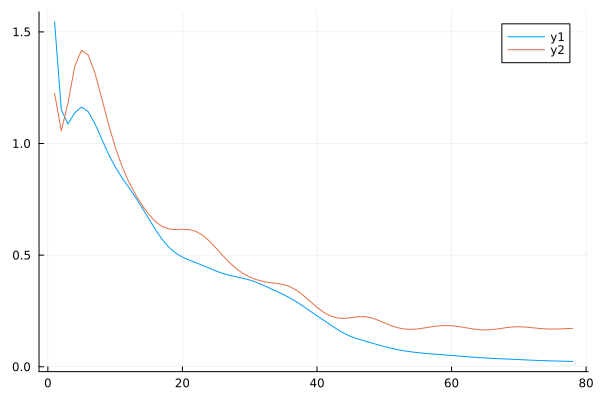

In [148]:
using Plots

p = plot(1:size(insights[2], 1), insights[2])
plot!(p, 1:size(insights[3], 1), insights[3])

In [149]:
try_ann = insights[1]
loss(model, x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y) # loss function
currentValidationLoss = loss(try_ann, valInputs', valLabels')

0.16477466f0

In [151]:
currentValidationLoss == insights[3][size(insights[3], 1) - patience]

true

In [156]:
output_data = try_ann(testInputs')
class_data = classifyOutputs(output_data')
accuracy(class_data, testLabels)

0.9565217391304348